In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

In [2]:
class Standard_CNN(nn.Module):
    def __init__(self):#modified vgg16+lenet5
        super().__init__()
        self.Conv1 = nn.Conv2d(1,6,kernel_size=3,stride=1,padding=1)#maxpooling doesnt change the cin or cout.. only downsample the picture
        self.Conv2 = nn.Conv2d(6,16,kernel_size=3,stride=1,padding=1)
        self.fc1    = nn.Linear(16*4*4,120)
        self.fc2    = nn.Linear(120,84)
        self.fc3    = nn.Linear(84,10)
    def forward(self,x):
        x = torch.relu(self.Conv1(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.relu(self.Conv2(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = x.view(-1,16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [3]:
transform = transforms.Compose(
    [transforms.Pad(padding=2),transforms.ToTensor()] #make the 28x28 fashionmnist picture 32x32
)

In [ ]:
# batch_size = 50
# data_root = "../FashionMNIST"
# trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
# testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
# trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
# testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
# device = torch.device(
#     "mps" if torch.backends.mps.is_available()
#     else "cuda" if torch.cuda.is_available()
#     else "cpu"
# )
# print(f"Using device: {device}")
# model = Standard_CNN().to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer1 = torch.optim.Adam(model.parameters(),lr=0.001)
# optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
# optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


100%|██████████| 26.4M/26.4M [00:09<00:00, 2.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 196kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.46MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Using device: cuda


In [56]:
from pathlib import Path
from torch.utils.data import ConcatDataset, DataLoader, Subset

In [57]:
batch_size = 50
data_root = "../FashionMNIST"
original_trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True)
original_testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True)

all_labels = torch.cat([
    original_trainset.targets,
    original_testset.targets,
])

split_seed = 42
split_generator = torch.Generator().manual_seed(split_seed)

train_indices = []
validation_indices = []
test_indices = []

for class_number in range(10): # stratified sampling so each class is balanced in train, validation, and test sets

    class_indices = torch.where(all_labels == class_number)[0]

    shuffled_order = torch.randperm(
        len(class_indices),
        generator=split_generator,
    )

    class_indices = class_indices[shuffled_order] #update to shufled order

    train_end = int(0.70 * len(class_indices))
    validation_end = train_end + int(0.15 * len(class_indices))

    train_indices.extend(class_indices[:train_end].tolist())

    validation_indices.extend(
        class_indices[train_end:validation_end].tolist()
    )

    test_indices.extend(class_indices[validation_end:].tolist())

print("Training images:", len(train_indices))
print("Validation images:", len(validation_indices))
print("Test images:", len(test_indices))


Training images: 49000
Validation images: 10500
Test images: 10500


In [52]:
def accuracy(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad(): # not train on evaluation
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [53]:
epochs = 20
adam_batch_losses = []
adam_train_losses = []
adam_train_accuracies = []
adam_test_accuracies = []
adam_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    adam_train_accuracies.append(train_acc)
    adam_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
adam_end = time.time()
adam_time = adam_end - adam_start
print("time for training", adam_time, "seconds")

RuntimeError: Given groups=1, weight of size [6, 1, 3, 3], expected input[50, 3, 224, 224] to have 1 channels, but got 3 channels instead

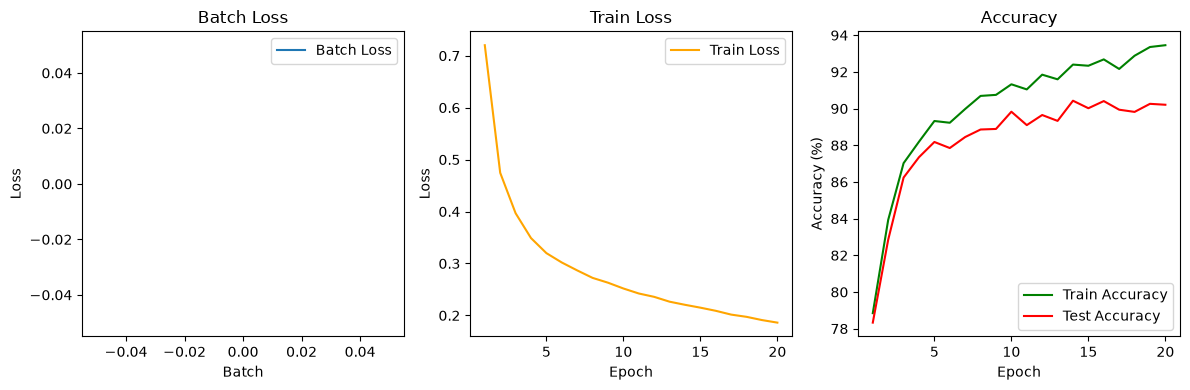

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(adam_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), adam_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
epochs = 20
sgd_batch_losses = []
sgd_train_losses = []
sgd_train_accuracies = []
sgd_test_accuracies = []
sgd_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_train_accuracies.append(train_acc)
    sgd_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_end = time.time()
sgd_time = sgd_end - sgd_start
print("time for training", sgd_time, "seconds")

Epoch 1/20 | Loss: 0.1636 | Train Acc: 94.18% | Test Acc: 90.99%
Epoch 2/20 | Loss: 0.1583 | Train Acc: 94.34% | Test Acc: 91.16%
Epoch 3/20 | Loss: 0.1559 | Train Acc: 94.34% | Test Acc: 91.14%
Epoch 4/20 | Loss: 0.1544 | Train Acc: 94.44% | Test Acc: 91.29%
Epoch 5/20 | Loss: 0.1531 | Train Acc: 94.48% | Test Acc: 91.30%
Epoch 6/20 | Loss: 0.1520 | Train Acc: 94.54% | Test Acc: 91.21%
Epoch 7/20 | Loss: 0.1514 | Train Acc: 94.58% | Test Acc: 91.25%
Epoch 8/20 | Loss: 0.1506 | Train Acc: 94.59% | Test Acc: 91.30%
Epoch 9/20 | Loss: 0.1501 | Train Acc: 94.59% | Test Acc: 91.31%
Epoch 10/20 | Loss: 0.1496 | Train Acc: 94.59% | Test Acc: 91.26%
Epoch 11/20 | Loss: 0.1492 | Train Acc: 94.61% | Test Acc: 91.39%
Epoch 12/20 | Loss: 0.1487 | Train Acc: 94.69% | Test Acc: 91.32%
Epoch 13/20 | Loss: 0.1482 | Train Acc: 94.67% | Test Acc: 91.38%
Epoch 14/20 | Loss: 0.1480 | Train Acc: 94.69% | Test Acc: 91.27%
Epoch 15/20 | Loss: 0.1477 | Train Acc: 94.66% | Test Acc: 91.29%
Epoch 16/20 | Loss:

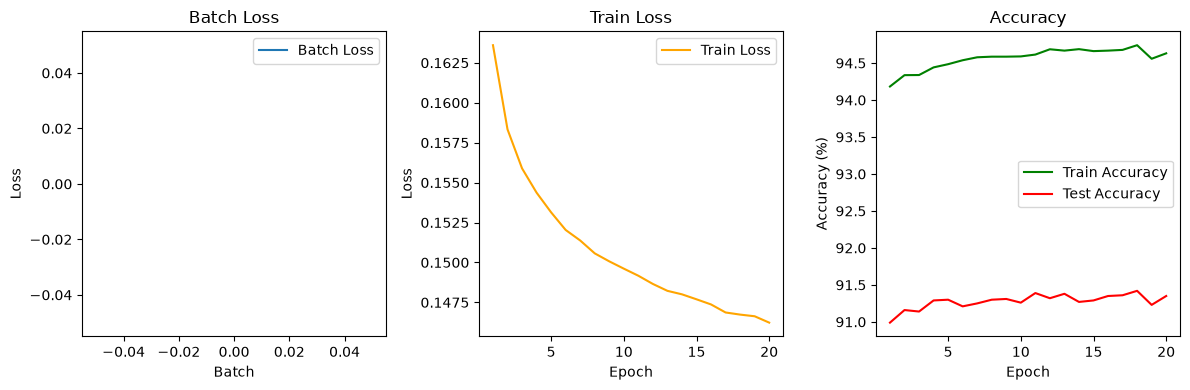

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
epochs = 20
sgd_m_batch_losses = []
sgd_m_train_losses = []
sgd_m_train_accuracies = []
sgd_m_test_accuracies = []
sgd_m_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer3.zero_grad()
        loss.backward()
        optimizer3.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_m_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_m_train_accuracies.append(train_acc)
    sgd_m_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_m_end = time.time()
sgd_m_time = sgd_m_end - sgd_m_start
print("time for training", sgd_m_time, "seconds")

Epoch 1/20 | Loss: 0.1567 | Train Acc: 94.22% | Test Acc: 90.99%
Epoch 2/20 | Loss: 0.1536 | Train Acc: 94.57% | Test Acc: 91.32%
Epoch 3/20 | Loss: 0.1536 | Train Acc: 94.46% | Test Acc: 90.95%
Epoch 4/20 | Loss: 0.1524 | Train Acc: 94.52% | Test Acc: 91.02%
Epoch 5/20 | Loss: 0.1511 | Train Acc: 94.81% | Test Acc: 91.21%
Epoch 6/20 | Loss: 0.1493 | Train Acc: 94.56% | Test Acc: 91.12%
Epoch 7/20 | Loss: 0.1485 | Train Acc: 94.69% | Test Acc: 91.38%
Epoch 8/20 | Loss: 0.1489 | Train Acc: 94.80% | Test Acc: 91.09%
Epoch 9/20 | Loss: 0.1473 | Train Acc: 95.01% | Test Acc: 91.30%
Epoch 10/20 | Loss: 0.1475 | Train Acc: 94.43% | Test Acc: 90.74%
Epoch 11/20 | Loss: 0.1471 | Train Acc: 94.40% | Test Acc: 90.82%
Epoch 12/20 | Loss: 0.1449 | Train Acc: 94.88% | Test Acc: 91.07%
Epoch 13/20 | Loss: 0.1445 | Train Acc: 94.95% | Test Acc: 91.15%
Epoch 14/20 | Loss: 0.1436 | Train Acc: 94.90% | Test Acc: 91.09%
Epoch 15/20 | Loss: 0.1428 | Train Acc: 94.87% | Test Acc: 90.97%
Epoch 16/20 | Loss:

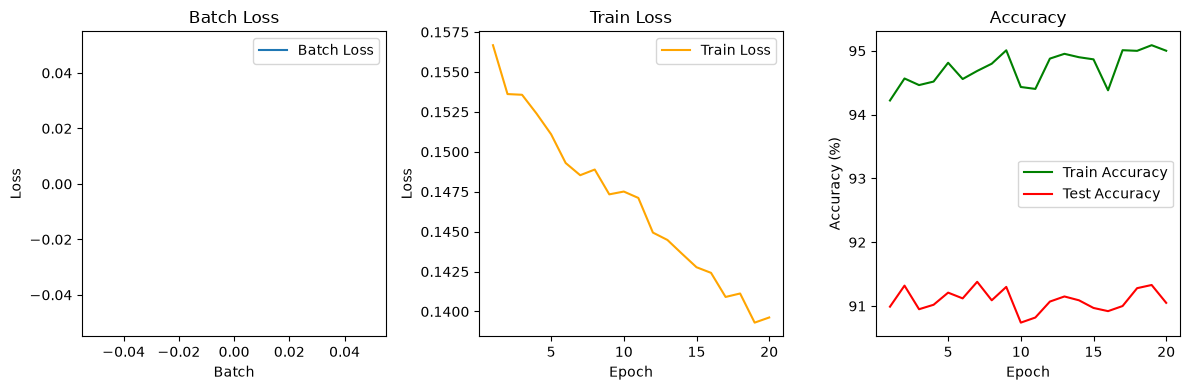

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_m_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_m_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_m_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_m_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
class DepthWise_Separable_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_depth = nn.Conv2d(1,1,kernel_size=3,padding=1,groups=1)
        self.batch_norm_1_1 = nn.BatchNorm2d(1)
        self.conv1_point = nn.Conv2d(1,6,kernel_size=1,groups=1)
        self.batch_norm_1_2 = nn.BatchNorm2d(6)
        self.conv2_depth = nn.Conv2d(6,6,kernel_size=3,padding=1,groups=6)
        self.batch_norm_2_1 = nn.BatchNorm2d(6)
        self.conv2_point = nn.Conv2d(6,16,kernel_size=1,groups=1)
        self.batch_norm_2_2 = nn.BatchNorm2d(16)
        self.fc1    = nn.Linear(16*4*4,120)
        self.fc2    = nn.Linear(120,84)
        self.fc3    = nn.Linear(84,10)

    def forward(self,x):
        x = self.conv1_depth(x)
        x = self.batch_norm_1_1(x)
        x = torch.relu(x)
        x = self.conv1_point(x)
        x = self.batch_norm_1_2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = self.conv2_depth(x)
        x = self.batch_norm_2_1(x)
        x = torch.relu(x)
        x = self.conv2_point(x)
        x = self.batch_norm_2_2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = x.view(-1,16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [14]:
transform = transforms.Compose(
    [transforms.Pad(padding=2),transforms.ToTensor()] #make the 28x28 fashionmnist picture 32x32
)

In [16]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = DepthWise_Separable_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model.parameters(),lr=0.001)
optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Using device: cuda


In [17]:
def accuracy(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [18]:
epochs = 20
adam_batch_losses_mobilenet = []
adam_train_losses_mobilenet = []
adam_train_accuracies_mobilenet = []
adam_test_accuracies_mobilenet = []
adam_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses_mobilenet.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    adam_train_accuracies_mobilenet.append(train_acc)
    adam_test_accuracies_mobilenet.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
adam_end = time.time()
adam_time = adam_end - adam_start
print("time for training", adam_time, "seconds")

Epoch 1/20 | Loss: 0.6191 | Train Acc: 80.11% | Test Acc: 78.70%
Epoch 2/20 | Loss: 0.4198 | Train Acc: 80.66% | Test Acc: 79.90%
Epoch 3/20 | Loss: 0.3701 | Train Acc: 86.17% | Test Acc: 84.86%
Epoch 4/20 | Loss: 0.3462 | Train Acc: 87.61% | Test Acc: 86.20%
Epoch 5/20 | Loss: 0.3290 | Train Acc: 88.31% | Test Acc: 86.58%
Epoch 6/20 | Loss: 0.3185 | Train Acc: 88.47% | Test Acc: 86.87%
Epoch 7/20 | Loss: 0.3087 | Train Acc: 88.67% | Test Acc: 87.00%
Epoch 8/20 | Loss: 0.2999 | Train Acc: 88.95% | Test Acc: 87.24%
Epoch 9/20 | Loss: 0.2910 | Train Acc: 89.36% | Test Acc: 87.50%
Epoch 10/20 | Loss: 0.2844 | Train Acc: 89.28% | Test Acc: 87.30%
Epoch 11/20 | Loss: 0.2798 | Train Acc: 89.85% | Test Acc: 87.54%
Epoch 12/20 | Loss: 0.2730 | Train Acc: 89.70% | Test Acc: 87.85%
Epoch 13/20 | Loss: 0.2676 | Train Acc: 89.45% | Test Acc: 87.33%
Epoch 14/20 | Loss: 0.2615 | Train Acc: 90.33% | Test Acc: 88.12%
Epoch 15/20 | Loss: 0.2567 | Train Acc: 90.43% | Test Acc: 88.15%
Epoch 16/20 | Loss:

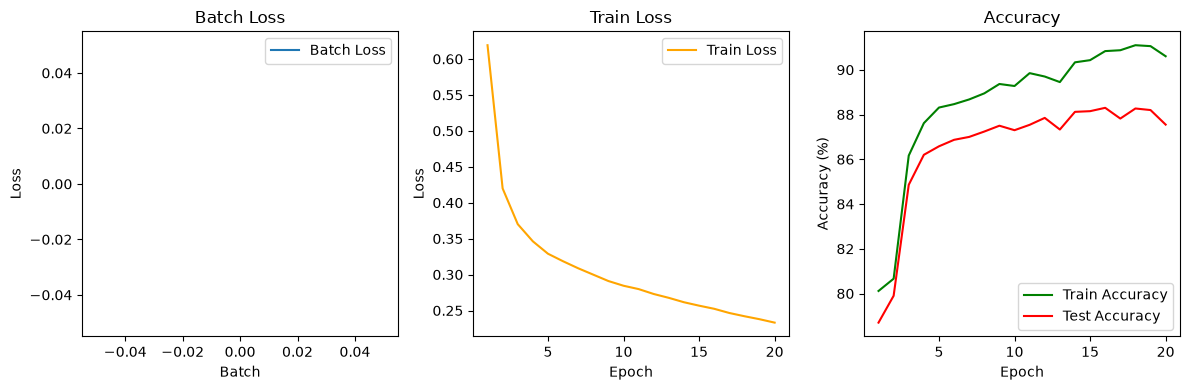

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(adam_batch_losses_mobilenet, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), adam_train_losses_mobilenet, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies_mobilenet, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies_mobilenet, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

SOTA models

In [20]:
from torchvision.models import MobileNet_V2_Weights

In [21]:
transform = transforms.Compose(
    [transforms.Resize(224),
     transforms.Grayscale(num_output_channels=3),
     transforms.ToTensor(),
     transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
     ] #make the 28x28 fashionmnist picture 32x32
)

In [22]:
model_pt = torchvision.models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
model_pt.classifier[1] = nn.Linear(model_pt.last_channel,10)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\asus/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:26<00:00, 529kB/s] 


In [23]:
for param in model_pt.parameters():
    param.requires_grad = False
for param in model_pt.classifier[1].parameters():
    param.requires_grad = True

In [24]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")
model_pt = model_pt.to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_pt.parameters()),lr=0.001)
#optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
#optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Using device: cuda


In [25]:
def accuracy(loader):
    model_pt.eval()
    correct, total = 0,0
    with torch.no_grad(): # not train on evaluation
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model_pt(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [31]:
epochs = 20
mobilenetv2_batch_losses = []
mobilenetv2_train_losses = []
mobilenetv2_train_accuracies = []
mobilenetv2_test_accuracies = []
mobilenetv2_start = time.time()
for epoch in range(epochs):
    model_pt.train()
    model_pt.features.eval() #??
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model_pt(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    mobilenetv2_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    mobilenetv2_train_accuracies.append(train_acc)
    mobilenetv2_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
mobilenetv2_end = time.time()
mobilenetv2_time = mobilenetv2_end - mobilenetv2_start
print("time for training", mobilenetv2_time, "seconds")

Epoch 1/20 | Loss: 0.2664 | Train Acc: 91.83% | Test Acc: 89.45%
Epoch 2/20 | Loss: 0.2658 | Train Acc: 92.06% | Test Acc: 89.60%
Epoch 3/20 | Loss: 0.2637 | Train Acc: 91.96% | Test Acc: 89.71%
Epoch 4/20 | Loss: 0.2649 | Train Acc: 92.02% | Test Acc: 89.62%
Epoch 5/20 | Loss: 0.2628 | Train Acc: 91.99% | Test Acc: 89.42%
Epoch 6/20 | Loss: 0.2634 | Train Acc: 91.94% | Test Acc: 89.65%
Epoch 7/20 | Loss: 0.2643 | Train Acc: 91.92% | Test Acc: 89.66%
Epoch 8/20 | Loss: 0.2630 | Train Acc: 92.09% | Test Acc: 89.64%
Epoch 9/20 | Loss: 0.2641 | Train Acc: 92.08% | Test Acc: 89.56%
Epoch 10/20 | Loss: 0.2644 | Train Acc: 92.16% | Test Acc: 89.65%
Epoch 11/20 | Loss: 0.2609 | Train Acc: 92.15% | Test Acc: 89.70%
Epoch 12/20 | Loss: 0.2607 | Train Acc: 91.99% | Test Acc: 89.32%
Epoch 13/20 | Loss: 0.2611 | Train Acc: 92.07% | Test Acc: 89.44%
Epoch 14/20 | Loss: 0.2583 | Train Acc: 92.04% | Test Acc: 89.54%
Epoch 15/20 | Loss: 0.2625 | Train Acc: 92.28% | Test Acc: 89.73%
Epoch 16/20 | Loss:

In [36]:
print(len(mobilenetv2_train_accuracies), len(mobilenetv2_test_accuracies))

21 20


In [38]:
mobilenetv2_train_accuracies.pop()

92.09833333333333

In [40]:
print(len(mobilenetv2_batch_losses))


0


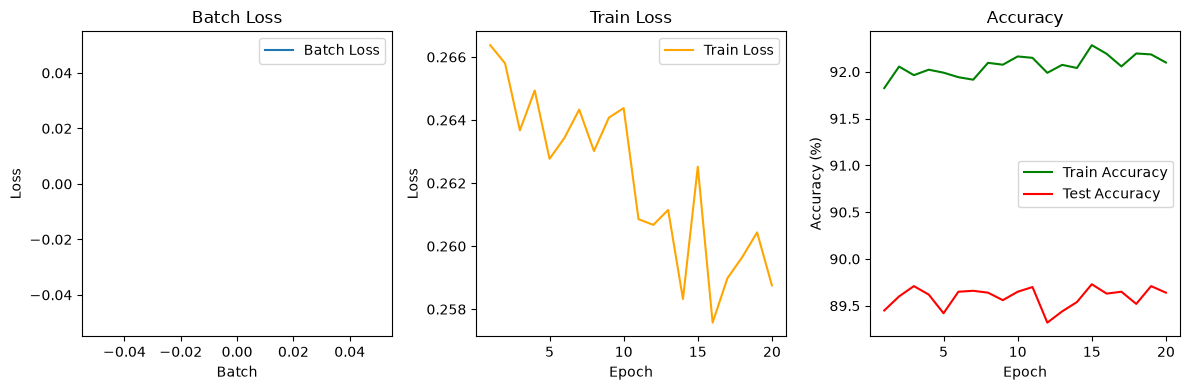

In [39]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(mobilenetv2_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), mobilenetv2_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(
    range(1, epochs + 1),     mobilenetv2_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), mobilenetv2_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
from torchvision.models import EfficientNet_B0_Weights

In [45]:

weights = EfficientNet_B0_Weights.DEFAULT

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(
        256,
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [46]:
model_pt = torchvision.models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_pt.classifier[1] = nn.Linear(
    model_pt.classifier[1].in_features, 10
)

In [47]:
for param in model_pt.parameters():
    param.requires_grad = False
for param in model_pt.classifier[1].parameters():
    param.requires_grad = True

In [48]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")
model_pt = model_pt.to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_pt.parameters()),lr=0.001)
#optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
#optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Using device: cuda


In [49]:
def accuracy(loader):
    model_pt.eval()
    correct, total = 0,0
    with torch.no_grad(): # not train on evaluation
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model_pt(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [50]:
epochs = 20
efficientnetB0_batch_losses = []
efficientnetB0_train_losses = []
efficientnetB0_train_accuracies = []
efficientnetB0_test_accuracies = []
efficientnetB0_start = time.time()
for epoch in range(epochs):
    model_pt.train()
    model_pt.features.eval() #??It keeps its BatchNorm statistics fixed and disables stochastic depth while the classifier trains.
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model_pt(images)
        loss = criterion(output, label)
        efficientnetB0_batch_losses.append(loss.item())
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    efficientnetB0_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    efficientnetB0_train_accuracies.append(train_acc)
    efficientnetB0_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
efficientnetB0_end = time.time()
efficientnetB0_time = efficientnetB0_end - efficientnetB0_start
print("time for training", efficientnetB0_time, "seconds")

Epoch 1/20 | Loss: 0.3971 | Train Acc: 89.80% | Test Acc: 88.83%
Epoch 2/20 | Loss: 0.2960 | Train Acc: 90.46% | Test Acc: 89.44%
Epoch 3/20 | Loss: 0.2784 | Train Acc: 91.27% | Test Acc: 89.99%
Epoch 4/20 | Loss: 0.2693 | Train Acc: 91.79% | Test Acc: 90.46%
Epoch 5/20 | Loss: 0.2606 | Train Acc: 91.83% | Test Acc: 90.49%
Epoch 6/20 | Loss: 0.2575 | Train Acc: 92.09% | Test Acc: 90.69%
Epoch 7/20 | Loss: 0.2523 | Train Acc: 92.31% | Test Acc: 90.73%
Epoch 8/20 | Loss: 0.2516 | Train Acc: 92.44% | Test Acc: 90.88%
Epoch 9/20 | Loss: 0.2496 | Train Acc: 92.49% | Test Acc: 90.91%
Epoch 10/20 | Loss: 0.2478 | Train Acc: 92.36% | Test Acc: 90.76%
Epoch 11/20 | Loss: 0.2467 | Train Acc: 92.47% | Test Acc: 90.61%
Epoch 12/20 | Loss: 0.2433 | Train Acc: 92.74% | Test Acc: 90.95%
Epoch 13/20 | Loss: 0.2435 | Train Acc: 92.54% | Test Acc: 90.95%
Epoch 14/20 | Loss: 0.2431 | Train Acc: 92.65% | Test Acc: 90.78%
Epoch 15/20 | Loss: 0.2414 | Train Acc: 92.73% | Test Acc: 91.15%
Epoch 16/20 | Loss: